# Setup Code (Imported from Tasks.ipynb)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter

In [2]:
df = pd.read_csv("Loan_default.csv")
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
df.drop("LoanID", axis=1, inplace=True)

In [4]:
X = df.drop("Default", axis=1)
y = df["Default"]


In [5]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=[np.number]).columns

In [6]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [7]:
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X[col] = np.clip(X[col], lower, upper)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
X_train = X_train.to_numpy(dtype=np.float64)
X_test  = X_test.to_numpy(dtype=np.float64)

y_train = y_train.to_numpy(dtype=np.float64)
y_test  = y_test.to_numpy(dtype=np.float64)

### Task - 5

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [12]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    # "SVM": SVC()
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(name, "CV Accuracy:", scores.mean())

Logistic Regression CV Accuracy: 0.8849797067034224
Decision Tree CV Accuracy: 0.8005355577880933
Random Forest CV Accuracy: 0.8850629278513846


In [13]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(name, "Test Accuracy:", acc)

Logistic Regression Test Accuracy: 0.8858429606422558
Decision Tree Test Accuracy: 0.8018993538280791
Random Forest Test Accuracy: 0.886449970628549


In [14]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [None, 5, 10]
# }

# rf = RandomForestClassifier()

# grid = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
# grid.fit(X_train, y_train)

# print("Best Parameters:", grid.best_params_)
# print("Best CV Accuracy:", grid.best_score_)


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 200],
    "max_depth": [5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)


Best Parameters: {'max_depth': 10, 'n_estimators': 50}
Best CV Accuracy: 0.8842747846066734


In [16]:
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Tuned Model Test Accuracy:", accuracy_score(y_test, y_pred))

Tuned Model Test Accuracy: 0.8849226551791658


In [17]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Training Accuracy: 0.8852783230613334
Test Accuracy: 0.8849226551791658


### Task - 6

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

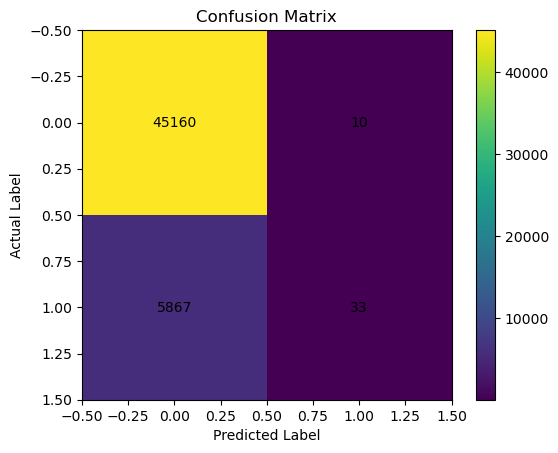

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


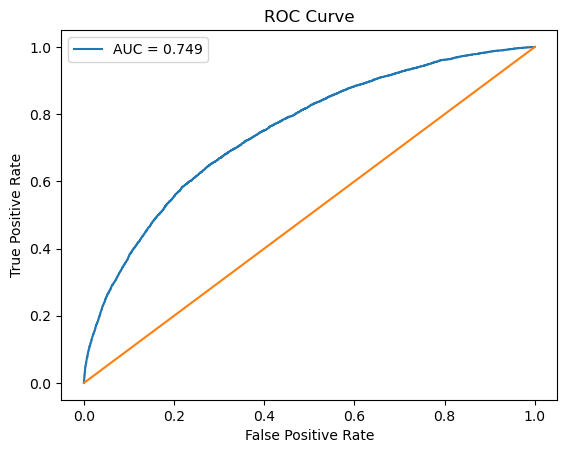

In [21]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc, 3)))
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


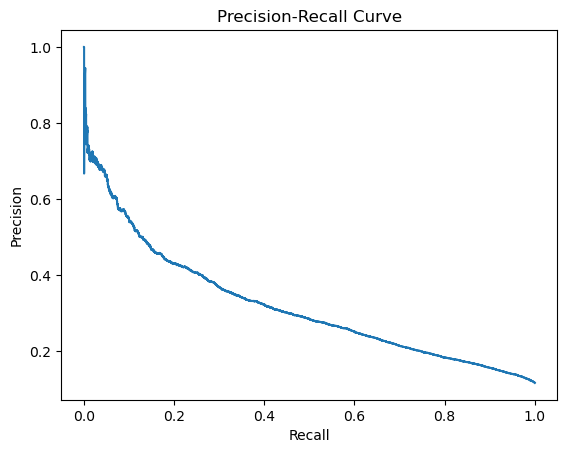

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


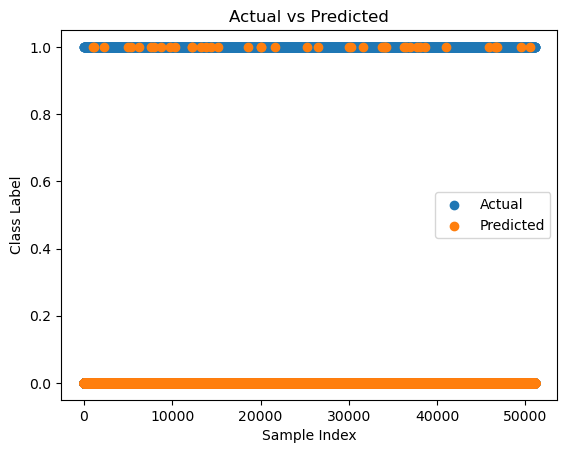

In [23]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()


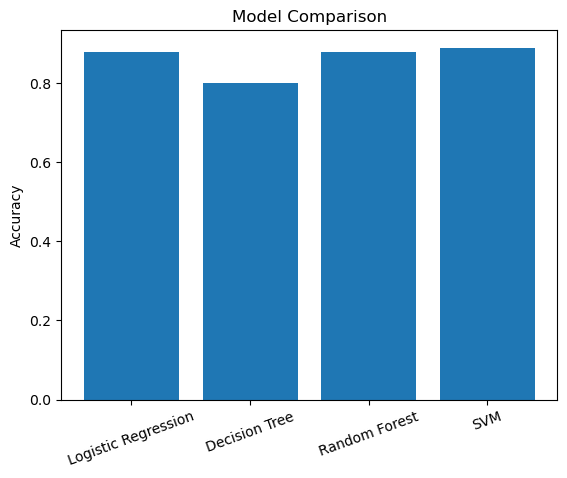

In [24]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
accuracies = [0.88, 0.80, 0.88, 0.89]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()


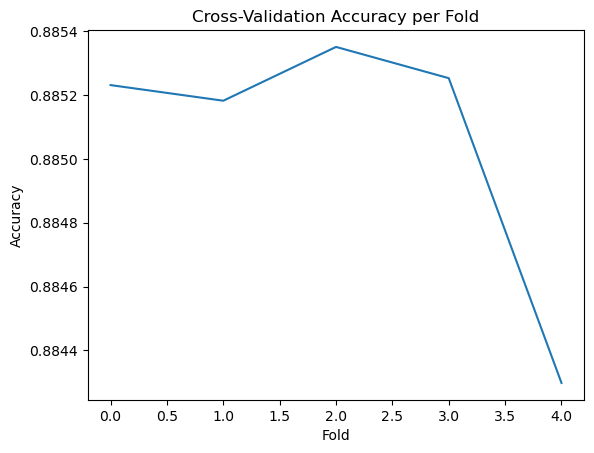

In [25]:
plt.figure()
plt.plot(scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracy per Fold")
plt.show()